In [1]:
# from PIL import Image
# import numpy as np
# import matplotlib.pyplot as plt
# root = '/home/adeel/New_Gass/GaussianLSS/data/nuscenes/'
# path = 'samples/CAM_FRONT/s-0a7db7cc06e4693969058a1f9603dc0f-2024-03-26_21-05-19_0849-096118817dfca67bd041775239117b8b.jpg'
# # path = 'samples/CAM_BACK_RIGHT/n008-2018-08-30-15-16-55-0400__CAM_BACK_RIGHT__1535657109278113.jpg'
# # path = 'samples/CAM_BACK_LEFT/n008-2018-08-30-15-16-55-0400__CAM_BACK_LEFT__1535657109297405.jpg'
# image = Image.open(root + path)
# image = np.asarray(image)
# plt.imshow(image)



In [2]:
# !pip install gsplat

In [3]:
import torch
import math

# ‼️ NEW: switch to gsplat’s drop-in wrapper for the Inria kernels
from gsplat import rasterization_inria_wrapper as rasterize

import os
import matplotlib.pyplot as plt


class BEVCamera:
    def __init__(self, x_range=(-50, 50), y_range=(-50, 50),
                 h=200, w=200, image_size=200, sh=0.8, sw=0.8):
        # Orthographic projection parameters
        self.x_min, self.x_max = x_range
        self.y_min, self.y_max = y_range
        self.image_width = image_size
        self.image_height = image_size

        # Set up FoV to cover the range [-50, 50] for both X and Y
        self.FoVx = (self.x_max - self.x_min)    # scene width in world coords
        self.FoVy = (self.y_max - self.y_min)    # scene height in world coords

        # Camera position (BEV): looking down the Z-axis
        self.camera_center = torch.tensor([0, 0, 0],
                                          dtype=torch.float32,
                                          device="cuda:0")

        # Orthographic projection matrix for BEV
        self.set_transform(h, w,
                           x_range[1] - x_range[0],
                           y_range[1] - y_range[0],
                           sh, sw)

    def set_transform(self, h=200, w=200,
                      h_meters=100, w_meters=100,
                      sh=0.5, sw=0.5):
        """Set up an orthographic projection matrix for BEV."""
        sh = 1 / sh
        sw = 1 / sw
        self.world_view_transform = torch.tensor([
            [0.,  sh, 0., 0.],
            [sw,  0., 0., 0.],
            [0.,  0., 0., 0.],
            [0.,  0., 0., 0.],
        ], dtype=torch.float32, device="cuda:0")

        self.full_proj_transform = torch.tensor([
            [0., -sh, 0.,  h / 2.],
            [-sw, 0., 0.,  w / 2.],
            [0.,  0., 0.,   1.],
            [0.,  0., 0.,   1.],
        ], dtype=torch.float32, device="cuda:0")

    def set_size(self, h, w):
        self.image_height = h
        self.image_width = w

In [4]:
import torch
import math
import os
import matplotlib.pyplot as plt

# NEW ➟ pull the native gsplat rasteriser
from gsplat.rendering import rasterization as gs_rasterize


# ————————————————————————————————————————
#  Synthetic-Gaussian generator (random-only)
# ————————————————————————————————————————
def generate_random_gaussians(num_gaussians, scaling_modifier=1.0):
    """
    Returns means3D, means2D, opacities, colors, cov6 for exactly `num_gaussians`.
    All Gaussians are random within a forward frustum-like region.
    """
    device = torch.device("cuda")
    N = int(num_gaussians)
    if N <= 0:
        raise ValueError("num_gaussians must be >= 1")

    # Random XY in front of the camera; Z in [0.0, 2.0]
    rand_x = torch.empty(N, device=device).uniform_(2.0, 25.0)
    rand_y = torch.empty(N, device=device).uniform_(-10.0, 10.0)
    rand_z = torch.empty(N, device=device).uniform_(0.0, 2.0)
    means3D = torch.stack([rand_x, rand_y, rand_z], dim=-1)

    # Opacities, colors
    opacities = torch.ones(N, device=device) * (1.0 - 0.01)
    colors_precomp = torch.ones(N, 128, device=device)

    # Covariance as upper-tri (xx,xy,xz,yy,yz,zz), modestly scaled by height
    base_cov = torch.tensor([1., 0., 0., 1., 0., 0.], device=device)
    cov6 = torch.stack([
        base_cov * (1.0 + scaling_modifier * 0.1 * (z / 10.0)) for z in means3D[:, 2]
    ])

    means2D = torch.zeros(N, 2, requires_grad=True, device=device)

    return means3D, means2D, opacities, colors_precomp, cov6

In [5]:
# Black background in a 128-channel feature space
bg_color = torch.zeros(128, dtype=torch.float32, device="cuda")

# Top-down BEV camera covering ±51.2 m at 200 px resolution
bev_camera = BEVCamera([-51.2, 51.2], [-51.2, 51.2],
                       h=200, w=200, image_size=200,
                       sh=0.5, sw=0.5)

# Define a BEV renderer that uses gsplat and returns render + meta

def render_random_gaussians(bev_camera, bg_color, num_gaussians=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # image size
    H, W = 200, 200
    # ranges from camera config
    x_range = (bev_camera.x_min, bev_camera.x_max)
    y_range = (bev_camera.y_min, bev_camera.y_max)
    # intrinsics for ortho mapping world->pixels
    fx_o = W / (y_range[1] - y_range[0])
    fy_o = H / (x_range[1] - x_range[0])
    cx_o, cy_o = W / 2.0, H / 2.0
    Ks_ortho = torch.tensor([[fx_o, 0.0, cx_o],
                             [0.0,  fy_o, cy_o],
                             [0.0,  0.0, 1.0]], dtype=torch.float32, device=device)[None, None, ...]
    # view matrix for top-down camera
    viewmat = torch.eye(4, dtype=torch.float32, device=device)
    viewmat[:3, :3] = torch.tensor([[ 0.0,  1.0,  0.0],
                                    [-1.0,  0.0,  0.0],
                                    [ 0.0,  0.0, -1.0]], dtype=torch.float32, device=device)
    viewmat[2, 3] = 10.0
    viewmats = viewmat[None, None, ...]

    # synthetic scene
    means3D, _m2D, opacities, colors, cov6 = generate_random_gaussians(num_gaussians)
    tri = ([0,0,0,1,1,2], [0,1,2,1,2,2])
    covars = torch.zeros((means3D.shape[0], 3, 3), device=means3D.device, dtype=torch.float32)
    covars[:, tri[0], tri[1]] = cov6

    # backgrounds [1,1,C]
    backgrounds = bg_color[None, None, :].to(means3D.dtype).to(means3D.device)

    # rasterize
    rendered, _alphas, meta = gs_rasterize(
        means       = means3D[None],     # [1,N,3]
        quats       = None,
        scales      = None,
        covars      = covars[None],      # [1,N,3,3]
        opacities   = opacities[None],   # [1,N]
        colors      = colors[None],      # [1,N,128]
        viewmats    = viewmats,          # [1,1,4,4]
        Ks          = Ks_ortho,          # [1,1,3,3]
        width       = W, height = H,
        backgrounds = backgrounds,       # [1,1,128]
        render_mode = "RGB",
        camera_model= "ortho",
        packed      = False,
    )

    return {
        "render": rendered.squeeze(0).squeeze(0),
        "means2d": meta["means2d"].squeeze(0).squeeze(0),
        "radii": meta["radii"].squeeze(0).squeeze(0),
        "visibility_filter": meta.get("visibility_filter", None),
    }

# Render five random Gaussians with the new gsplat-powered pipeline
output = render_random_gaussians(bev_camera, bg_color, num_gaussians=5)

Visibility: None
Radii-px  : tensor([[7, 7],
        [7, 7],
        [7, 7],
        [7, 7],
        [7, 7]], device='cuda:0', dtype=torch.int32)


(-0.5, 199.5, 199.5, -0.5)

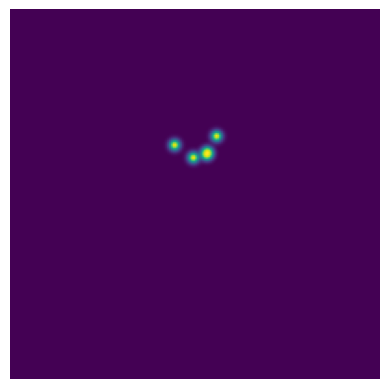

In [6]:
print("Visibility:", output["visibility_filter"])
print("Radii-px  :", output["radii"])
plt.imshow(output["render"][:, :, 0].cpu(), cmap="viridis"); plt.axis("off")

In [7]:
import math
import torch
import torch.nn.functional as F

def render_perspective(view_pos, look_at, bg_color, num_gaussians=5,
                       H=400, W=400, fov_deg=60.0, flip_vertical=True):
    """
    Pin-hole render of the toy Gaussians (single batch, single camera).
    - view_pos, look_at: (x,y,z) tuples/lists in *world* coords
    - flip_vertical=True makes 'image up is up' (negates fy)
    Uses right-axis so +Y_world projects to +u (right) to match BEV mapping.
    """
    device = torch.device("cuda")

    # --- intrinsics (square pixels) -----------------------------------------
    fov_rad = math.radians(fov_deg)
    fx = fy = 0.5 * W / math.tan(0.5 * fov_rad)
    K = torch.tensor([[fx, 0,  W / 2],
                      [0,  fy, H / 2],
                      [0,   0,   1]],
                     dtype=torch.float32, device=device)[None, None, ...]  # [1,1,3,3]
    if flip_vertical:
        K = K.clone()
        K[..., 1, 1] *= -1  # make fy negative so v-up (up is up)

    # --- view matrix (standard look-at; Z-up world) -------------------------
    view_pos = torch.tensor(view_pos, dtype=torch.float32, device=device)
    look_at  = torch.tensor(look_at,  dtype=torch.float32, device=device)
    up_world = torch.tensor([0., 0., 1.], dtype=torch.float32, device=device)

    z_cam = F.normalize(look_at - view_pos, dim=0)              # forward (+Z_cam)
    # Right axis so +Y_world maps to +u: x_cam = cross(up, z)
    x_cam = F.normalize(torch.cross(up_world, z_cam), dim=0)    # right
    y_cam = F.normalize(torch.cross(z_cam, x_cam), dim=0)       # up

    R = torch.stack((x_cam, y_cam, z_cam), dim=0)               # 3x3
    t = -R @ view_pos

    viewmat = torch.eye(4, dtype=torch.float32, device=device)
    viewmat[:3, :3] = R
    viewmat[:3,  3] = t
    viewmats = viewmat[None, None, ...]                         # [1,1,4,4]

    # --- toy Gaussians ------------------------------------------------------
    means3D, _, opacities, colors, cov6 = generate_random_gaussians(num_gaussians)
    tri = ([0,0,0,1,1,2], [0,1,2,1,2,2])
    covars = torch.zeros((means3D.shape[0], 3, 3), device=device, dtype=torch.float32)
    covars[:, tri[0], tri[1]] = cov6
    covars = covars[None]                                       # [1,N,3,3]

    # --- rasterize (explicit pinhole) --------------------------------------
    rendered, _, _ = gs_rasterize(
        means       = means3D[None],      # [1,N,3]
        quats       = None,
        scales      = None,
        opacities   = opacities[None],    # [1,N]
        colors      = colors[None],       # [1,N,128]
        viewmats    = viewmats,           # [1,1,4,4]
        Ks          = K,                  # [1,1,3,3]
        width       = W, height = H,
        backgrounds = bg_color[None, None, :],  # [1,1,128]
        render_mode = "RGB",
        camera_model= "pinhole",
        covars      = covars,
        packed      = False
    )

    return rendered.squeeze(0).squeeze(0)[:, :, 0].cpu()

(-0.5, 399.5, 399.5, -0.5)

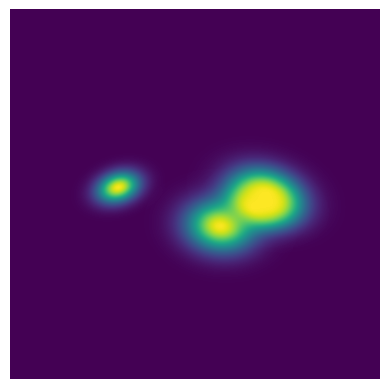

In [8]:
bg = torch.zeros(128, device="cuda")

img_gray = render_perspective(
    view_pos=(-8.0, 0.0, 1.5),
    look_at =(10.0, 0.0, 1.5),
    bg_color=bg,
    num_gaussians=5,
    flip_vertical=True,
)
plt.imshow(img_gray, cmap="viridis"); plt.axis("off")

## Gaussian ↔ pixel correspondences across views

This section tracks the same Gaussian in both orthographic and perspective views using rasterizer meta (means2d, radii). It provides:
- Gaussian-level mapping: for Gaussian i, its 2D centers in both views.
- Pixel-level mapping via Gaussians: assign a pixel to its nearest Gaussian (within radius), then map to the other view via that Gaussian’s center.

Notes:
- Requires meta from both renders (packed=False) with fields: 'means2d' and 'radii'.
- If needed, re-render each view to collect meta. Ensure both renders use the same Gaussians ordering.

In [9]:
# Track Gaussians across ortho and perspective without changing camera poses (no plots)
import math
import torch

from gsplat.rendering import rasterization as gs_rasterize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Always generate a fresh set of 5 random Gaussians for both views
num_gaussians = 5
means3D, _m2D_unused, opacities, colors, cov6 = generate_random_gaussians(num_gaussians)
means3D, opacities, colors, cov6 = means3D.to(device), opacities.to(device), colors.to(device), cov6.to(device)
# Build covars [N,3,3] from 6D upper-tri (xx,xy,xz,yy,yz,zz)
tri = ([0, 0, 0, 1, 1, 2], [0, 1, 2, 1, 2, 2])
covars = torch.zeros((cov6.shape[0], 3, 3), device=device, dtype=torch.float32)
covars[:, tri[0], tri[1]] = cov6

# Ortho (top-down)
H_ortho, W_ortho = 200, 200
x_range = (-51.2, 51.2)
y_range = (-51.2, 51.2)
fx_o = W_ortho / (y_range[1] - y_range[0])
fy_o = H_ortho / (x_range[1] - x_range[0])
cx_o, cy_o = W_ortho / 2.0, H_ortho / 2.0
Ks_ortho = torch.tensor([[fx_o, 0.0, cx_o],
                         [0.0,  fy_o, cy_o],
                         [0.0,  0.0, 1.0]], dtype=torch.float32, device=device)[None, None, ...]
viewmat_o = torch.eye(4, dtype=torch.float32, device=device)
viewmat_o[:3, :3] = torch.tensor([[ 0.0,  1.0,  0.0],
                                  [-1.0,  0.0,  0.0],
                                  [ 0.0,  0.0, -1.0]], dtype=torch.float32, device=device)
viewmat_o[2, 3] = 10.0
viewmats_ortho = viewmat_o[None, None, ...]

# Perspective — v-up and corrected right axis
H_persp, W_persp = 400, 400
fov_deg = 60.0
fov_rad = math.radians(fov_deg)
fx = fy = 0.5 * W_persp / math.tan(0.5 * fov_rad)
Ks_persp = torch.tensor([[fx, 0.0, W_persp / 2.0],
                         [0.0,  fy, H_persp / 2.0],
                         [0.0,  0.0, 1.0]], dtype=torch.float32, device=device)[None, None, ...]
Ks_persp = Ks_persp.clone(); Ks_persp[..., 1, 1] *= -1
view_pos = torch.tensor([-8.0, 0.0, 1.5], dtype=torch.float32, device=device)
look_at  = torch.tensor([10.0, 0.0, 1.5], dtype=torch.float32, device=device)
up_world = torch.tensor([0.0, 0.0, 1.0], dtype=torch.float32, device=device)
z_cam = torch.nn.functional.normalize(look_at - view_pos, dim=0)
x_cam = torch.nn.functional.normalize(torch.cross(up_world, z_cam), dim=0)
y_cam = torch.nn.functional.normalize(torch.cross(z_cam, x_cam), dim=0)
R = torch.stack((x_cam, y_cam, z_cam), dim=0)
t = -R @ view_pos
viewmat_p = torch.eye(4, dtype=torch.float32, device=device)
viewmat_p[:3, :3] = R
viewmat_p[:3,  3] = t
viewmats_persp = viewmat_p[None, None, ...]

# Rendering helper

def render_with_meta(means3D, covars, opacities, colors, viewmats, Ks, H, W, camera_model):
    bg = torch.zeros(colors.shape[-1], device=colors.device, dtype=colors.dtype)[None, None]
    rendered, _alphas, meta = gs_rasterize(
        means       = means3D[None],
        quats       = None,
        scales      = None,
        covars      = covars[None],
        opacities   = opacities[None],
        colors      = colors[None],
        viewmats    = viewmats,
        Ks          = Ks,
        width       = W, height = H,
        backgrounds = bg,
        render_mode = "RGB",
        camera_model= camera_model,
        packed      = False,
    )
    img = rendered.squeeze(0).squeeze(0)
    means2d = meta["means2d"].squeeze(0).squeeze(0)
    radii   = meta["radii"].squeeze(0).squeeze(0)
    return img, means2d, radii

# Render both views
img_o, m2_o, r_o = render_with_meta(means3D, covars, opacities, colors, viewmats_ortho, Ks_ortho, H_ortho, W_ortho, camera_model="ortho")
img_p, m2_p, r_p = render_with_meta(means3D, covars, opacities, colors, viewmats_persp, Ks_persp, H_persp, W_persp, camera_model="pinhole")

G = m2_o.shape[0]
assert m2_p.shape[0] == G, "Mismatch in number of Gaussians between renders"

gaussian_correspondences = {
    'indices': torch.arange(G, device=device),
    'ortho_centers': m2_o,
    'persp_centers': m2_p,
    'ortho_radii': r_o,
    'persp_radii': r_p,
}

print('Gaussian index  |  Ortho (u,v)  ->  Persp (u,v)')
for i in range(min(G, 50)):
    uo, vo = m2_o[i].detach().cpu().numpy().tolist()
    up, vp = m2_p[i].detach().cpu().numpy().tolist()
    print(f'{i:>6d}          |  ({uo:6.1f},{vo:6.1f})  ->  ({up:6.1f},{vp:6.1f})')
print(f"Total Gaussians mapped: {G}")

Gaussian index  |  Ortho (u,v)  ->  Persp (u,v)
     0          |  (  86.8,  61.5)  ->  ( 115.5, 215.7)
     1          |  ( 118.7,  75.4)  ->  ( 361.6, 194.7)
     2          |  (  88.9,  66.7)  ->  ( 121.8, 218.9)
     3          |  ( 105.5,  69.0)  ->  ( 240.8, 217.2)
     4          |  (  89.0,  77.4)  ->  ( 100.5, 216.1)
Total Gaussians mapped: 5


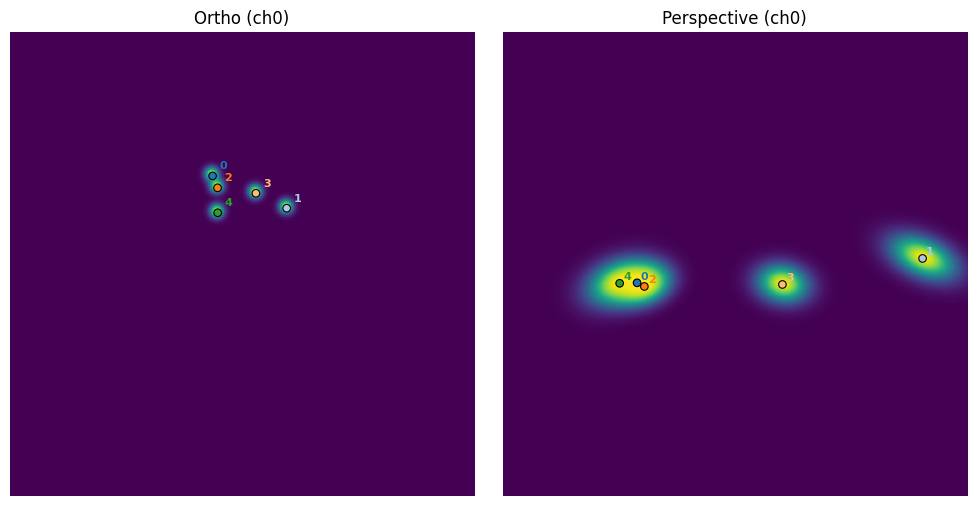

In [10]:
# Visualize ortho and perspective renders with Gaussian centers overlaid
import torch
import matplotlib.pyplot as plt
import numpy as np


def _to_numpy_img(img: torch.Tensor):
    x = img
    if isinstance(x, torch.Tensor):
        if x.dim() == 3 and x.shape[-1] >= 1:
            x = x[..., 0]  # show channel 0 as grayscale
        return x.detach().cpu().numpy()
    return x

# Build a consistent color per Gaussian index
def _colors_for_N(N):
    # tab20 gives 20 distinct colors; cycle if N>20
    cmap = plt.get_cmap('tab20')
    cols = np.array([cmap(i % 20) for i in range(N)])
    return cols

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Ortho
bev_img = _to_numpy_img(img_o)
axs[0].imshow(bev_img, cmap="viridis")
axs[0].set_title("Ortho (ch0)")
axs[0].axis("off")
if 'm2_o' in globals():
    pts = m2_o.detach().cpu().numpy()
    C = _colors_for_N(len(pts))
    axs[0].scatter(pts[:, 0], pts[:, 1], s=30, c=C, marker='o', linewidths=0.8, edgecolors='k')
    for i in range(min(len(pts), 50)):
        axs[0].text(pts[i, 0] + 3, pts[i, 1] - 3, str(i), color=C[i], fontsize=8, weight='bold')

# Perspective
persp_img = _to_numpy_img(img_p)
axs[1].imshow(persp_img, cmap="viridis")
axs[1].set_title("Perspective (ch0)")
axs[1].axis("off")
if 'm2_p' in globals():
    pts = m2_p.detach().cpu().numpy()
    C = _colors_for_N(len(pts))
    axs[1].scatter(pts[:, 0], pts[:, 1], s=30, c=C, marker='o', linewidths=0.8, edgecolors='k')
    for i in range(min(len(pts), 50)):
        axs[1].text(pts[i, 0] + 3, pts[i, 1] - 3, str(i), color=C[i], fontsize=8, weight='bold')

plt.tight_layout()
